# 4,9% de los adultos blancos. 13,5% de los hombres blancos de 18 a 29.

Explícale a un adulto blanco de Estados Unidos qué defiende el movimiento nacionalista blanco y después pregúntale si lo apoya. En una muestra probabilística de 2.114 personas, 4,9% dice que sí — casi 1 de cada 20. Entre los hombres de 18 a 29 años, 13,5%. Y en otra encuesta, de 3.227 personas, preguntar sin la explicación previa deja el apoyo expresado en la mitad de lo que sale preguntando con ella.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Egan, Bisbee & Tucker (2026). *Predictors and prevalence of support for white nationalism in the United States*. **Nature**

**DOI:** [10.1038/s41586-026-11018-0](https://doi.org/10.1038/s41586-026-11018-0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-16-nacionalismo-blanco-predictores-eeuu/notebook.ipynb)

**Video:** Pendiente

## Qué midieron

Hasta ahora las encuestas trataban el nacionalismo blanco como algo que se infiere por rodeos: actitudes raciales, resentimiento, identidad. Este equipo hizo otra cosa: le describe al encuestado los principios centrales del movimiento (en resumen: que Estados Unidos debería ser un país de y para blancos) y le pregunta directamente si apoya al movimiento. Lo que miden es **apoyo expresado**, no afiliación a ninguna organización — el paper lo subraya y nosotros también.

Tres encuestas nacionales de adultos blancos no hispanos entre 2021 y 2025. Aquí abrimos las dos que están en el repositorio de replicación: **Study 1** (CES/YouGov 2021, panel online opt-in, n = 3.227) y **Study 2** (NORC AmeriSpeak 2024, muestra probabilística reclutada offline, n = 2.114). El Study 3 (CloudResearch, 2024-25) solo aparece como una fila del Source Data — el archivo de datos suplementario que Nature exige junto al paper.

Dentro de cada encuesta hay un experimento: a la mitad, elegida al azar, le muestran la descripción del movimiento *antes* de preguntar; a la otra mitad le preguntan a secas y luego le muestran la descripción y vuelven a preguntar. Ese contraste es la única parte causal del estudio. Todo lo demás — edad, ingreso, condado, amistades — es asociación, y así lo vamos a leer. Todos los porcentajes van ponderados con los pesos de cada encuesta.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
N_SUBMUESTRAS = 10_000       # cuántos grupos aleatorios simular en el cierre
SEMILLA = 42                 # reproducibilidad de la simulación
GRUPO_FOCO = ('Male', '18-29')   # subgrupo del Study 2 que comparamos contra el azar

FUENTE = ('Fuente: Egan, Bisbee & Tucker (2026), Nature | '
          'Datos: Harvard Dataverse 10.7910/DVN/J6G51T + Source Data del paper')
COLOR_DATOS = '#2563EB'        # azul CaM
COLOR_ALERTA = '#DC2626'       # rojo
COLOR_SECUNDARIO = '#059669'   # verde
COLOR_REFERENCIA = '#D97706'   # ámbar
COLOR_CONTEXTO = '#BBBBBB'     # gris

# ── Setup ──────────────────────────────────────────────────────
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

BASE = ('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/'
        'papers/2026-09-16-nacionalismo-blanco-predictores-eeuu')

# Estilo CaM (local → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)


def cargar(nombre):
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)


# ── Helpers: estadística ponderada (mismas fórmulas que el R de los autores) ──
def media_se_ponderada(y, w):
    """Media ponderada y su error estándar: sqrt(sum(w²(y−m)²)) / sum(w)."""
    y = np.asarray(y, float)
    w = np.asarray(w, float)
    m = np.sum(w * y) / np.sum(w)
    se = np.sqrt(np.sum(w**2 * (y - m) ** 2)) / np.sum(w)
    return m, se


def test_proporciones(y1, w1, y2, w2):
    """z-test de dos proporciones ponderadas. Devuelve (p1, p2, diferencia, z, p-valor)."""
    m1, se1 = media_se_ponderada(y1, w1)
    m2, se2 = media_se_ponderada(y2, w2)
    z = (m2 - m1) / np.sqrt(se1**2 + se2**2)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return m1, m2, m2 - m1, z, p


def cohen_h(p1, p2):
    """Tamaño del efecto para dos proporciones: |2·asin√p1 − 2·asin√p2|."""
    return abs(2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2)))


def fmt_es(x, dec=1):
    """Formato español: coma decimal, punto de miles."""
    s = f'{x:,.{dec}f}'
    return s.replace(',', 'X').replace('.', ',').replace('X', '.')


# ── Carga ──────────────────────────────────────────────────────
s1 = cargar('study1_ces_2021.csv')                 # microdatos Study 1 (CES/YouGov 2021)
s2 = cargar('study2_norc_2024.csv')                # microdatos Study 2 (NORC 2024)
s2 = s2.dropna(subset=['apoya_nacionalismo_blanco'])   # 32 filas skipped/refused → fuera
fig4 = cargar('fig4_edad_genero_pooled.csv')       # prevalencia por edad × género, S1 + S2 (Source Data Fig. 4)

print(f'Study 1: {fmt_es(len(s1), 0)} encuestados, {s1.shape[1]} columnas')
print(f'Study 2: {fmt_es(len(s2), 0)} encuestados con respuesta, {s2.shape[1]} columnas')
print(f'Fig. 4:  {len(fig4)} celdas edad × género, n = {fmt_es(fig4.n_unweighted.sum(), 0)} (S1 + S2)')

prev_s2, se_s2 = media_se_ponderada(s2.apoya_nacionalismo_blanco, s2.peso)
print(f'\nPrevalencia ponderada Study 2: {fmt_es(prev_s2*100)}% '
      f'(IC95 {fmt_es((prev_s2-1.96*se_s2)*100)}–{fmt_es((prev_s2+1.96*se_s2)*100)})')
prev_s1, se_s1 = media_se_ponderada(s1.apoya_nacionalismo_blanco, s1.peso)
print(f'Prevalencia ponderada Study 1 (toda la muestra, tras la descripción): {fmt_es(prev_s1*100)}%')

Study 1: 3.227 encuestados, 28 columnas
Study 2: 2.114 encuestados con respuesta, 18 columnas
Fig. 4:  124 celdas edad × género, n = 5.120 (S1 + S2)

Prevalencia ponderada Study 2: 4,9% (IC95 3,6–6,2)
Prevalencia ponderada Study 1 (toda la muestra, tras la descripción): 6,7%


## Aquí está.

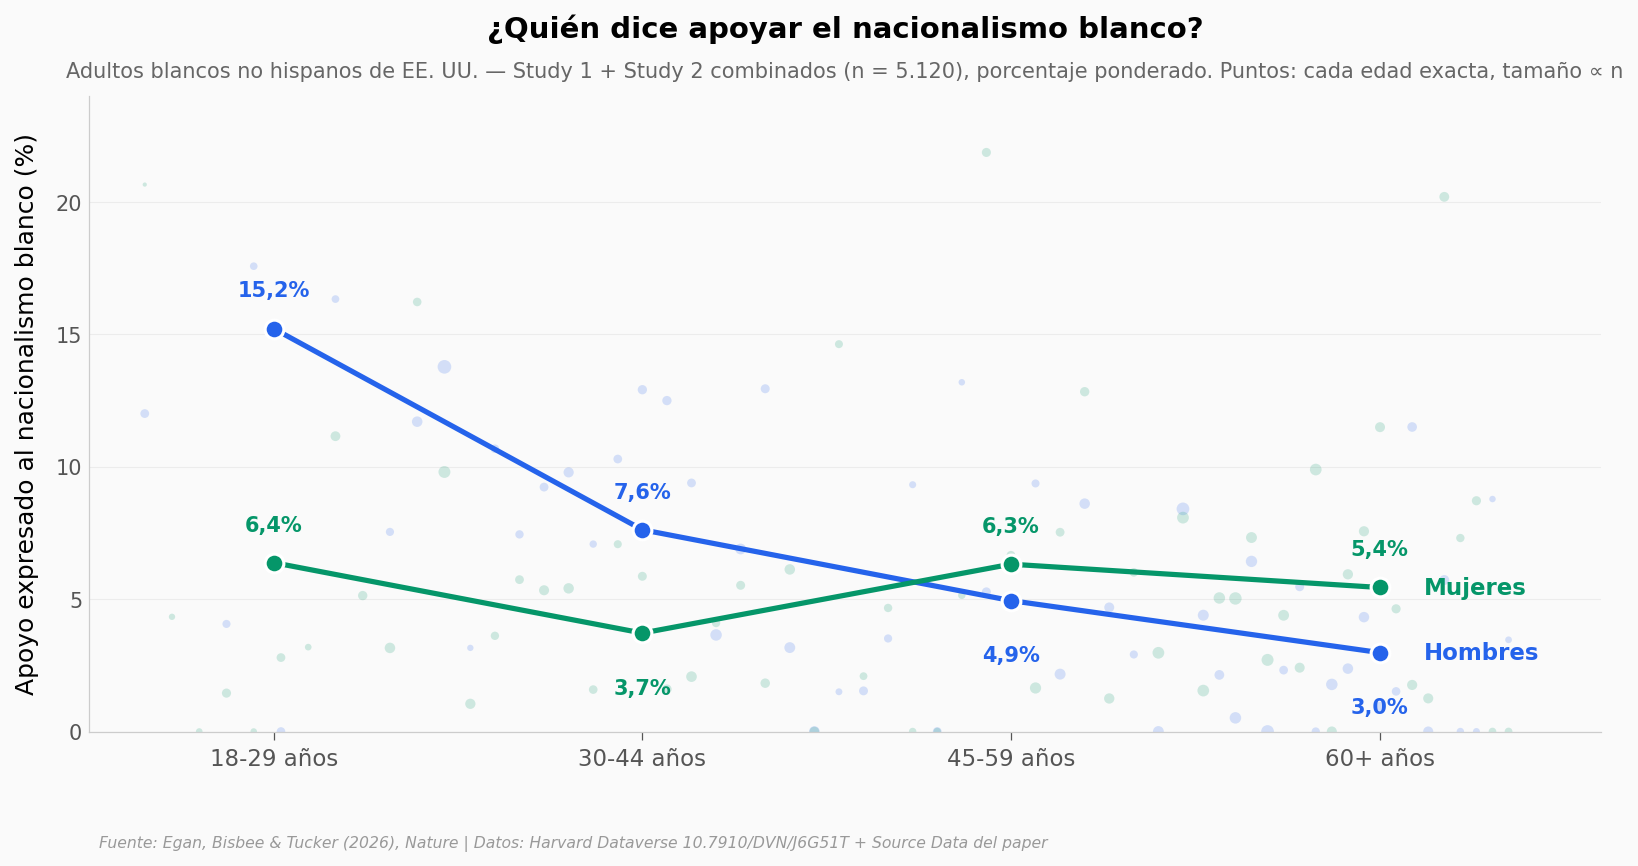

gender    Men  Women
tramo               
18-29   15.22   6.38
30-44    7.62   3.72
45-59    4.95   6.32
60+      2.98   5.44

n por celda:
gender  Men  Women
tramo             
18-29   300    401
30-44   561    691
45-59   597    626
60+     931   1013


In [2]:
# Prevalencia por edad × género, Study 1 + Study 2 combinados (Source Data Fig. 4).
# Cada fila del CSV es una edad exacta (18-79) × género con su media ponderada y su n.
# Agrupamos en 4 tramos de edad ponderando por n_weighted, como hace el paper.
bins = [17, 29, 44, 59, 200]
etiquetas = ['18-29', '30-44', '45-59', '60+']
fig4['tramo'] = pd.cut(fig4.age, bins=bins, labels=etiquetas)

tramos = (fig4.groupby(['gender', 'tramo'], observed=True)
              .apply(lambda g: pd.Series({
                  'pct': np.average(g.mean_prop, weights=g.n_weighted) * 100,
                  'n': g.n_unweighted.sum()}), include_groups=False)
              .astype({'n': int})
              .reset_index())

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(etiquetas))
series = [('Men', 'Hombres', COLOR_DATOS), ('Women', 'Mujeres', COLOR_SECUNDARIO)]

# Fondo: cada edad exacta como punto (tamaño ∝ n) — para ver el ruido detrás de las medias
for g, nombre, color in series:
    sub = fig4[fig4.gender == g]
    xs = np.interp(sub.age, [18, 29.5, 44.5, 59.5, 79], [-0.35, 0.5, 1.5, 2.5, 3.35])
    ax.scatter(xs, sub.mean_prop * 100, s=sub.n_weighted * 0.5, color=color,
               alpha=0.18, edgecolors='none', zorder=2)

# Medias por tramo
for g, nombre, color in series:
    t = tramos[tramos.gender == g].set_index('tramo').loc[etiquetas]
    ax.plot(x, t.pct, color=color, linewidth=2.5, marker='o', markersize=9,
            markeredgecolor='white', markeredgewidth=1.5, zorder=5)
    # Etiquetas arriba o abajo del punto según quién queda encima en cada tramo
    arriba = {'Men': [True, True, False, False], 'Women': [True, False, True, True]}[g]
    for xi, (pct, up) in enumerate(zip(t.pct, arriba)):
        ax.text(xi, pct + (1.2 if up else -2.3), f'{fmt_es(pct)}%', ha='center', fontsize=10,
                fontweight='bold', color=color, zorder=6)
    ax.text(3.12, t.pct.iloc[-1], nombre, fontsize=11, fontweight='bold', color=color, va='center')

ax.set_xticks(x)
ax.set_xticklabels([f'{e} años' for e in etiquetas], fontsize=11)
ax.set_ylabel('Apoyo expresado al nacionalismo blanco (%)')
ax.set_ylim(0, 24)
ax.set_xlim(-0.5, 3.6)
ax.set_title('¿Quién dice apoyar el nacionalismo blanco?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Adultos blancos no hispanos de EE. UU. — Study 1 + Study 2 combinados '
        '(n = 5.120), porcentaje ponderado. Puntos: cada edad exacta, tamaño ∝ n',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_edad_genero.png', dpi=200, bbox_inches='tight')
plt.show()

print(tramos.pivot(index='tramo', columns='gender', values='pct').round(2))
print('\nn por celda:')
print(tramos.pivot(index='tramo', columns='gender', values='n'))

Lo que llama la atención es la asimetría. En los hombres el apoyo cae de forma monótona con la edad: 15,2% entre 18 y 29 años, 7,6% entre 30 y 44, 5,0% entre 45 y 59, 3,0% a partir de los 60. Cinco veces menos de punta a punta. En las mujeres no hay pendiente: 6,4%, 3,7%, 6,3%, 5,4% — sube y baja sin dirección. El paper estima la interacción edad × género en un modelo ponderado y le sale p = 0,018.

Dos avisos antes de seguir. Primero, esta gráfica combina las dos encuestas (5.120 personas en el Source Data; el paper habla de 5.088 porque excluye algunas celdas). Los puntos de fondo enseñan lo ruidosa que es cada edad por separado: hay años con 7 personas. Segundo, la cifra de 13,5% del titular sale solo del Study 2, la encuesta probabilística, donde los hombres de 18 a 29 son 137. Con ese n el intervalo del 95% va de 5,0% a 22,0%. Es un intervalo ancho y hay que decirlo: lo sólido es que el grupo destaca, no el decimal.

## ¿Importa que te expliquen qué es antes de preguntar?

Es la parte experimental. A la mitad de cada muestra le describieron el movimiento antes de la pregunta; a la otra mitad le preguntaron sin más. Como la asignación fue al azar, la diferencia entre los dos grupos es efecto de la descripción, no de quién es cada persona. Lo calculamos desde los microdatos con el mismo test que usan los autores.

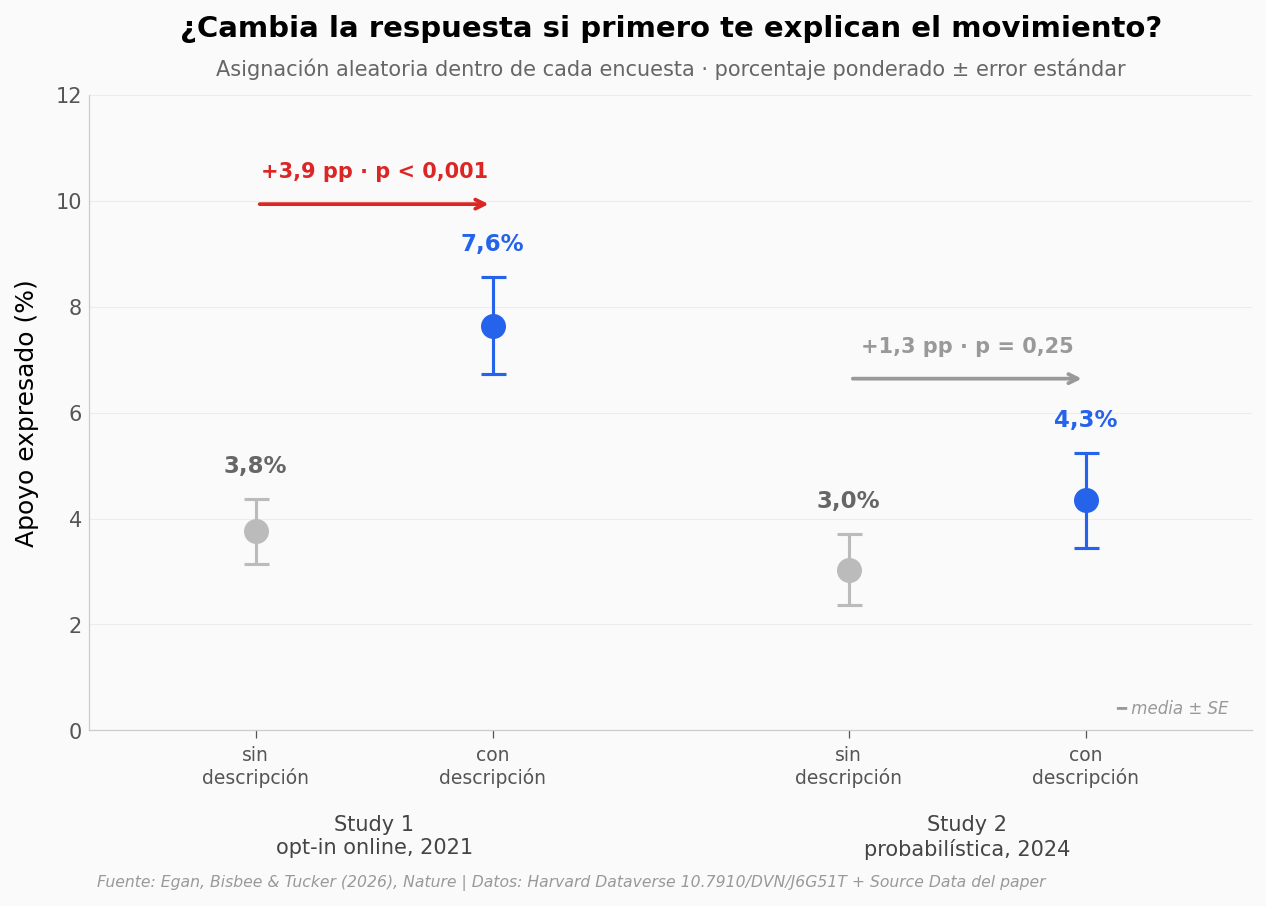

Study 1: sin descripción 3,76% (n=1617) → con descripción 7,64% (n=1610) | 3,88 pp, z = 3,52, p = 0,00043, ratio 2,03×, Cohen h = 0,170
Study 2: sin descripción 3,04% (n=1064) → con descripción 4,34% (n=1039) | 1,31 pp, z = 1,16, p = 0,25, ratio 1,43×, Cohen h = 0,070


In [3]:
# Control = preguntados SIN descripción (primera respuesta). Tratamiento = CON descripción.
resultados = {}
for nombre, df in [('Study 1', s1), ('Study 2', s2)]:
    ctl = df[df.grupo_experimental == 'control'].dropna(subset=['apoya_sin_descripcion'])
    trt = df[df.grupo_experimental == 'treated'].dropna(subset=['apoya_con_descripcion'])
    p1, p2, dif, z, p = test_proporciones(ctl.apoya_sin_descripcion, ctl.peso,
                                          trt.apoya_con_descripcion, trt.peso)
    _, se1 = media_se_ponderada(ctl.apoya_sin_descripcion, ctl.peso)
    _, se2 = media_se_ponderada(trt.apoya_con_descripcion, trt.peso)
    resultados[nombre] = dict(p_ctl=p1, p_trt=p2, se_ctl=se1, se_trt=se2, dif=dif, z=z, p=p,
                              h=cohen_h(p1, p2), n_ctl=len(ctl), n_trt=len(trt))

fig, ax = plt.subplots(figsize=(10, 5.5))
pos = {'Study 1': (0, 1), 'Study 2': (2.5, 3.5)}
for nombre, r in resultados.items():
    xc, xt = pos[nombre]
    for xi, pct, se, etiqueta, color in [(xc, r['p_ctl'], r['se_ctl'], 'Sin descripción', COLOR_CONTEXTO),
                                         (xt, r['p_trt'], r['se_trt'], 'Con descripción', COLOR_DATOS)]:
        ax.errorbar(xi, pct * 100, yerr=se * 100, fmt='o', color=color, markersize=11,
                    capsize=6, capthick=1.5, elinewidth=1.5, zorder=5)
        ax.text(xi, pct * 100 + se * 100 + 0.5, f'{fmt_es(pct*100)}%', ha='center',
                fontsize=11, fontweight='bold', color=color if color != COLOR_CONTEXTO else '#666666')
    # Flecha del efecto
    y_arrow = max(r['p_trt'], r['p_ctl']) * 100 + 2.3
    ax.annotate('', xy=(xt, y_arrow), xytext=(xc, y_arrow),
                arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA if r['p'] < 0.05 else '#999999', lw=1.8))
    signo = '+' if r['dif'] > 0 else ''
    p_txt = 'p < 0,001' if r['p'] < 0.001 else f'p = {fmt_es(r["p"], 2)}'
    ax.text((xc + xt) / 2, y_arrow + 0.5, f'{signo}{fmt_es(r["dif"]*100)} pp · {p_txt}',
            ha='center', fontsize=10, fontweight='bold',
            color=COLOR_ALERTA if r['p'] < 0.05 else '#999999')
    ax.text((xc + xt) / 2, -1.6, f'{nombre}\n' + ('opt-in online, 2021' if nombre == 'Study 1' else 'probabilística, 2024'),
            ha='center', va='top', fontsize=10, color='#444444')

ax.set_xticks([0, 1, 2.5, 3.5])
ax.set_xticklabels(['sin\ndescripción', 'con\ndescripción'] * 2, fontsize=9)
ax.set_ylabel('Apoyo expresado (%)')
ax.set_ylim(0, 12)
ax.set_xlim(-0.7, 4.2)
ax.set_title('¿Cambia la respuesta si primero te explican el movimiento?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Asignación aleatoria dentro de cada encuesta · porcentaje ponderado ± error estándar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SE', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.08, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/experimento_descripcion.png', dpi=200, bbox_inches='tight')
plt.show()

for nombre, r in resultados.items():
    p_es = f"{r['p']:.2g}".replace('.', ',')
    print(f"{nombre}: sin descripción {fmt_es(r['p_ctl']*100, 2)}% (n={r['n_ctl']}) → "
          f"con descripción {fmt_es(r['p_trt']*100, 2)}% (n={r['n_trt']}) | "
          f"{fmt_es(r['dif']*100, 2)} pp, z = {fmt_es(r['z'], 2)}, p = {p_es}, "
          f"ratio {fmt_es(r['p_trt']/r['p_ctl'], 2)}×, Cohen h = {fmt_es(r['h'], 3)}")

En el Study 1 la descripción duplica el apoyo expresado: de 3,8% a 7,6% (+3,9 puntos, p < 0,001). El tamaño del efecto es pequeño en términos de Cohen h (0,17), pero es un efecto de duplicar una proporción, y es la encuesta grande. En el Study 2 el salto es de 3,0% a 4,3% (+1,3 puntos) y no llega a significativo (p = 0,25): la muestra probabilística tenía poder para detectar unos 2,5 puntos, dice el paper, y este efecto quedó por debajo. Así que "se duplica" vale para el Study 1 y solo para el Study 1.

Lo que sí sugieren las dos encuestas juntas es que hay gente que apoya las ideas sin conocer la etiqueta — de eso va la celda experimental del final.

## Tres explicaciones sobre la mesa

El paper pone a prueba tres familias de teorías con los datos del Study 1. **Strain** (tensión): la gente que atraviesa dificultades personales sería más receptiva (el paper también mide el distress social del condado; aquí replicamos solo el indicador personal). **Status threat** (amenaza de estatus): el apoyo crecería donde la población blanca es minoría o está perdiendo peso. **Movilización online**: el apoyo sería mayor entre quienes tienen sus vínculos más cercanos en internet. Tomamos un indicador de cada una y recalculamos las medias ponderadas desde los microdatos.

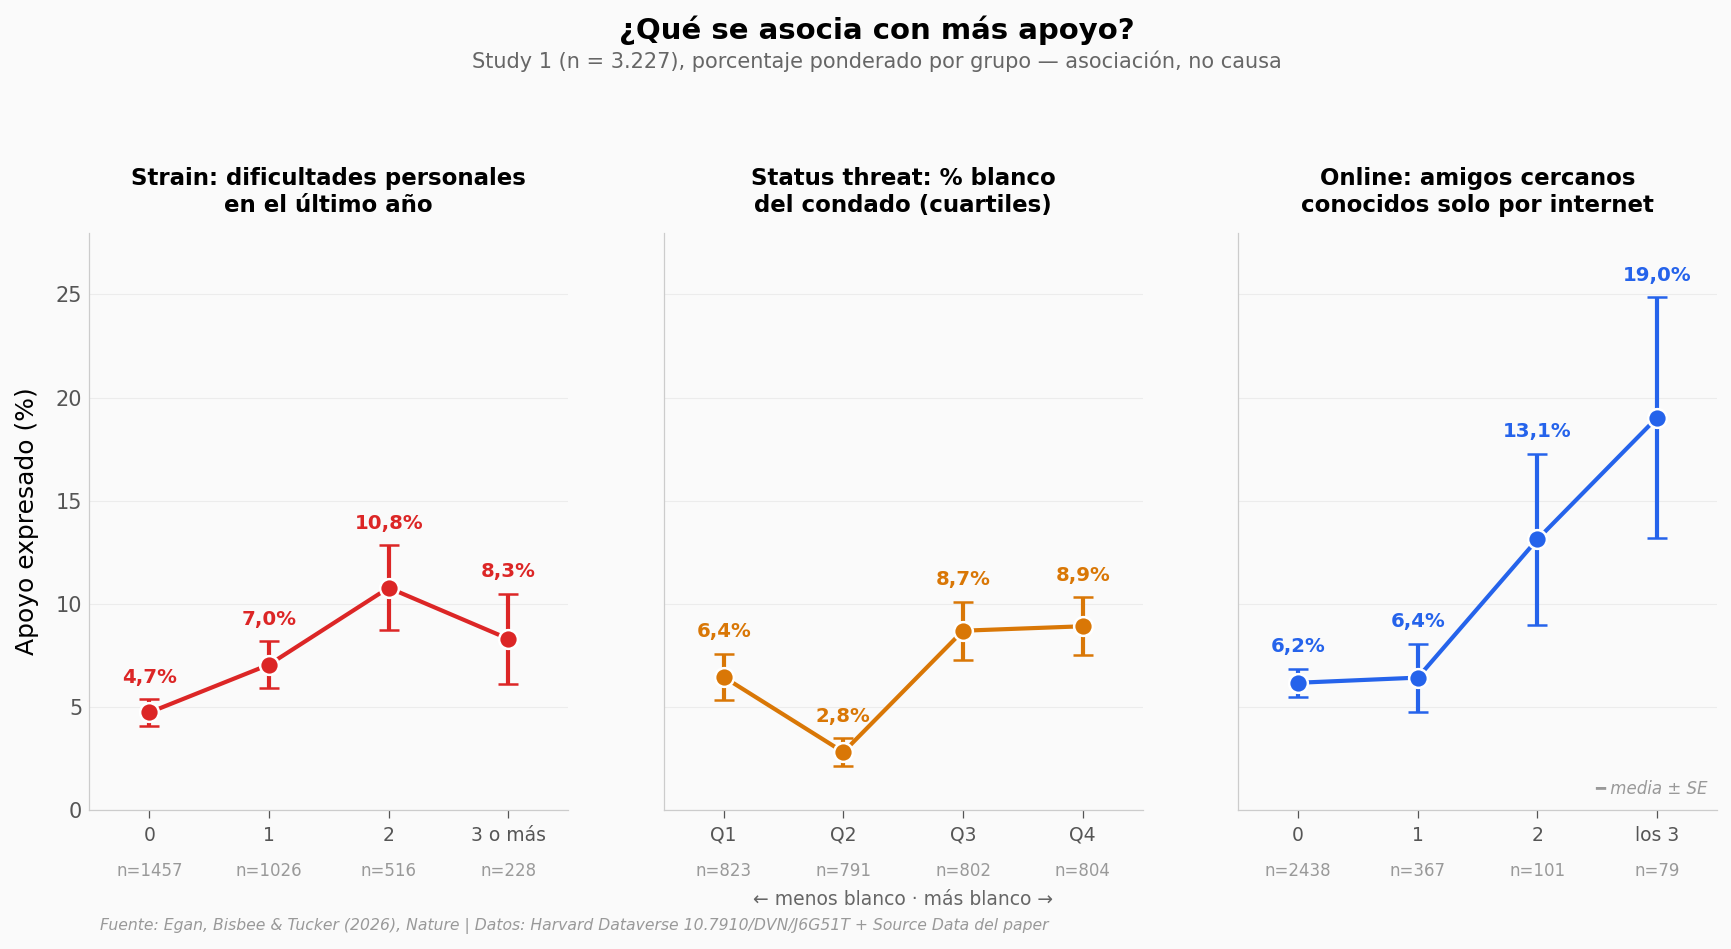

Strain: dificultades personales en el último año
  grupo   pct   se    n
      0  4.73 0.65 1457
      1  7.05 1.14 1026
      2 10.77 2.07  516
3 o más  8.30 2.19  228 

Status threat: % blanco del condado (cuartiles)
grupo  pct   se   n
   Q1 6.45 1.12 823
   Q2 2.81 0.66 791
   Q3 8.69 1.40 802
   Q4 8.91 1.41 804 

Online: amigos cercanos conocidos solo por internet
grupo   pct   se    n
    0  6.17 0.69 2438
    1  6.42 1.65  367
    2 13.12 4.16  101
los 3 19.03 5.83   79 

Cohen h dificultades 2 vs 0: 0,231 | amigos online los 3 vs 0: 0,401
Spearman % blanco del condado vs apoyo (sin peso): ρ = 0,032, p = 0,068


In [4]:
# Un indicador por teoría, Study 1 (observacional). Medias ponderadas ± SE y n por grupo.
def por_grupo(df, grupos):
    filas = []
    for etiqueta, mask in grupos:
        sub = df[mask]
        m, se = media_se_ponderada(sub.apoya_nacionalismo_blanco, sub.peso)
        filas.append((etiqueta, m * 100, se * 100, len(sub)))
    return pd.DataFrame(filas, columns=['grupo', 'pct', 'se', 'n'])

# (a) Strain: número de dificultades personales en el último año (muerte cercana, despido, ruptura...)
d = s1.dificultades_personales_n
strain = por_grupo(s1, [('0', d == 0), ('1', d == 1), ('2', d == 2), ('3 o más', d >= 3)])

# (b) Status threat: % de población blanca del condado en 2019, en cuartiles
q = pd.qcut(s1.condado_pct_blanco_2019, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
threat = por_grupo(s1, [(lab, q == lab) for lab in q.cat.categories])

# (c) Online: de sus 3 amigos más cercanos, cuántos conoció solo por internet (242 sin respuesta)
a = s1.amigos_solo_online_n
online = por_grupo(s1, [('0', a == 0), ('1', a == 1), ('2', a == 2), ('los 3', a == 3)])

paneles = [
    ('Strain: dificultades personales\nen el último año', strain, COLOR_ALERTA),
    ('Status threat: % blanco\ndel condado (cuartiles)', threat, COLOR_REFERENCIA),
    ('Online: amigos cercanos\nconocidos solo por internet', online, COLOR_DATOS),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, (titulo, tabla, color) in zip(axes, paneles):
    x = np.arange(len(tabla))
    ax.errorbar(x, tabla.pct, yerr=tabla.se, fmt='o-', color=color, markersize=9,
                linewidth=2, capsize=5, capthick=1.3, markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    for xi, (pct, n) in enumerate(zip(tabla.pct, tabla.n)):
        ax.text(xi, pct + tabla.se.iloc[xi] + 0.8, f'{fmt_es(pct)}%', ha='center', fontsize=9.5,
                fontweight='bold', color=color)
        ax.text(xi, -3.2, f'n={n}', ha='center', fontsize=8, color='#999999')
    ax.set_xticks(x)
    ax.set_xticklabels(tabla.grupo, fontsize=9)
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=10)
    ax.set_ylim(0, 28)
    ax.set_xlim(-0.5, len(tabla) - 0.5)
axes[0].set_ylabel('Apoyo expresado (%)')
axes[1].set_xlabel('← menos blanco · más blanco →', fontsize=9, color='#666666', labelpad=22)
axes[2].text(0.98, 0.02, '━ media ± SE', transform=axes[2].transAxes, fontsize=8,
             color='#999999', ha='right', va='bottom', style='italic')

fig.suptitle('¿Qué se asocia con más apoyo?', fontsize=14, fontweight='bold', y=1.17)
fig.text(0.5, 1.10, 'Study 1 (n = 3.227), porcentaje ponderado por grupo — asociación, no causa',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tres_teorias.png', dpi=200, bbox_inches='tight')
plt.show()

for titulo, tabla, _ in paneles:
    print(titulo.replace('\n', ' '))
    print(tabla.round(2).to_string(index=False), '\n')

print(f'Cohen h dificultades 2 vs 0: {fmt_es(cohen_h(strain.pct[2]/100, strain.pct[0]/100), 3)} | '
      f'amigos online los 3 vs 0: {fmt_es(cohen_h(online.pct[3]/100, online.pct[0]/100), 3)}')
rho, p_rho = stats.spearmanr(s1.condado_pct_blanco_2019, s1.apoya_nacionalismo_blanco, nan_policy='omit')
print(f'Spearman % blanco del condado vs apoyo (sin peso): ρ = {fmt_es(rho, 3)}, p = {fmt_es(p_rho, 3)}')

Las tres teorías no salen igual de bien paradas. Con las **dificultades personales** el apoyo sube de 4,7% (ninguna) a 7,1% (una) y 10,8% (dos) (Cohen h = 0,23 frente al grupo sin dificultades, pequeño), pero con tres o más baja a 8,3% — ese último grupo tiene 228 personas y un error estándar de 2,2 puntos, así que no es una curva limpia, es una tendencia con ruido al final. Encaja con la teoría del strain sin demostrarla. Con el **porcentaje de población blanca del condado** no hay patrón: 6,5%, 2,8%, 8,7%, 8,9% de menos a más blanco, y una correlación de rangos de ρ = 0,032 (p = 0,07). El paper lo resume como "sin relación", y los datos no le llevan la contraria: la amenaza de estatus, al menos medida así, no aparece. Con los **amigos conocidos solo por internet** el salto es el más grande de la gráfica — de 6,2% con ninguno a 19,0% cuando los tres amigos más cercanos son de internet (Cohen h = 0,40, mediano) — pero los dos grupos altos tienen 101 y 79 personas, de ahí las barras largas.

Todo esto es Study 1 y todo es asociación. Quien tiene tres amigos solo online no es más partidario *por* eso; los datos dicen que ambas cosas van juntas y nada más.

## ¿Qué tan raro es el 13,5% de los hombres jóvenes?

Con 137 personas, un porcentaje puede salir alto por azar. Una forma de verlo: sacar 10.000 grupos aleatorios de 137 personas del Study 2 completo, calcular el apoyo ponderado en cada uno y mirar cuántas veces llega a 13,5%.

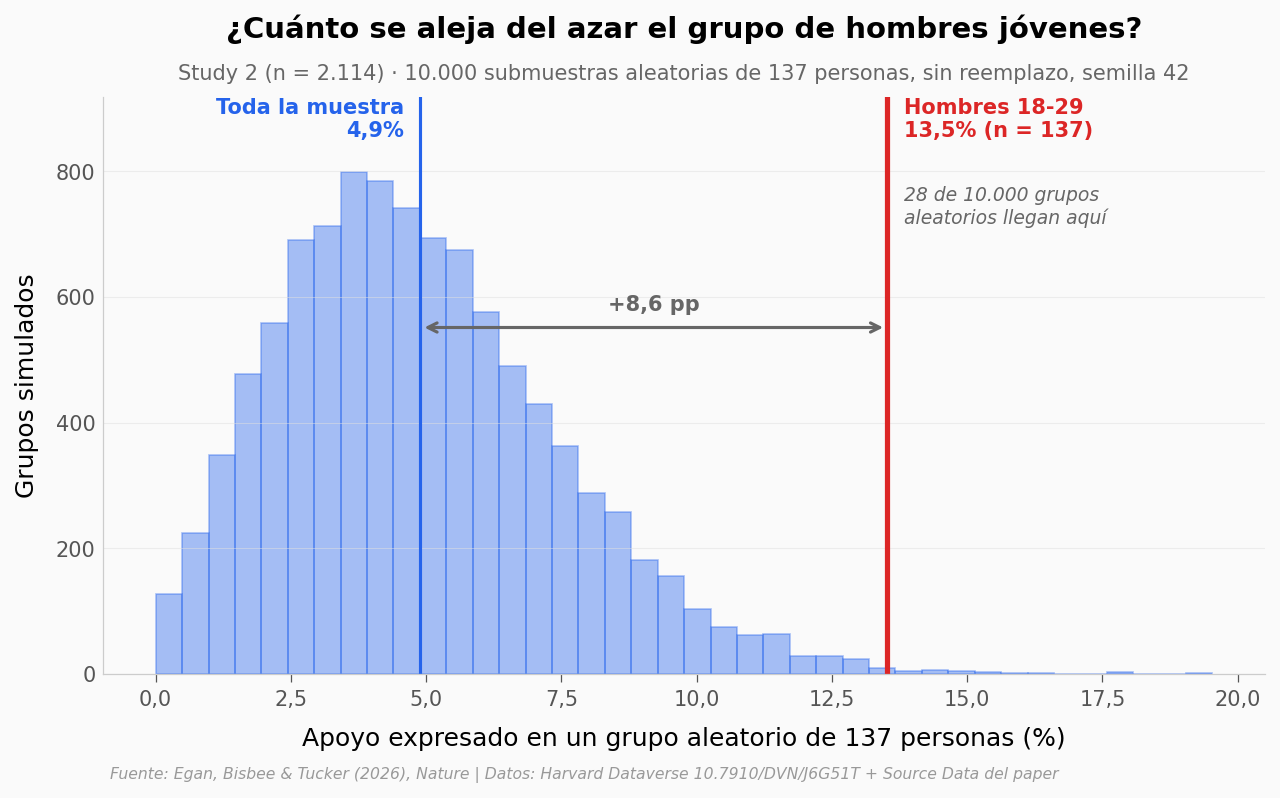

Hombres 18-29 (Study 2): 13,52% ± 4,35 SE, n = 137 — IC95 5,0–22,0%
Resto de la muestra: 4,04% → ratio 3,34×, Cohen h = 0,348
Submuestras: media 4,87%, p95 9,49%, p99 11,97%, máximo 19,53%
Grupos con apoyo ≥ 13,52%: 28 de 10.000 (0,28%)


In [5]:
# Distribución de referencia: prevalencia ponderada en grupos aleatorios del mismo tamaño
# que los hombres de 18-29 del Study 2, sacados de toda la muestra sin reemplazo.
foco = s2[(s2.genero == GRUPO_FOCO[0]) & (s2.edad_grupo == GRUPO_FOCO[1])]
p_foco, se_foco = media_se_ponderada(foco.apoya_nacionalismo_blanco, foco.peso)
resto = s2.drop(foco.index)
p_resto, _ = media_se_ponderada(resto.apoya_nacionalismo_blanco, resto.peso)
n_foco = len(foco)

rng = np.random.default_rng(SEMILLA)
y = s2.apoya_nacionalismo_blanco.to_numpy(float)
w = s2.peso.to_numpy(float)
sims = np.empty(N_SUBMUESTRAS)
for i in range(N_SUBMUESTRAS):
    idx = rng.choice(len(y), size=n_foco, replace=False)
    sims[i] = np.sum(w[idx] * y[idx]) / np.sum(w[idx])
sims *= 100
obs = p_foco * 100
n_iguales_o_mayores = int((sims >= obs).sum())

fig, ax = plt.subplots(figsize=(10, 5))
n_hist, bins_h, _ = ax.hist(sims, bins=40, color=COLOR_DATOS, alpha=0.4,
                            edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_hist.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(prev_s2 * 100, color=COLOR_DATOS, linewidth=1.5)
ax.axvline(obs, color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(obs, y_max * 0.6), xytext=(prev_s2 * 100, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((obs + prev_s2 * 100) / 2, y_max * 0.63, f'+{fmt_es(obs - prev_s2*100)} pp',
        ha='center', fontsize=10, color='#666666', fontweight='bold')
ax.text(prev_s2 * 100 - 0.3, y_max * 0.93, f'Toda la muestra\n{fmt_es(prev_s2*100)}%',
        ha='right', fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(obs + 0.3, y_max * 0.93, f'Hombres 18-29\n{fmt_es(obs)}% (n = {n_foco})',
        ha='left', fontsize=10, color=COLOR_ALERTA, fontweight='bold')
ax.text(obs + 0.3, y_max * 0.78,
        f'{n_iguales_o_mayores} de {fmt_es(N_SUBMUESTRAS, 0)} grupos\naleatorios llegan aquí',
        ha='left', fontsize=9, color='#666666', style='italic')

ax.set_xlabel('Apoyo expresado en un grupo aleatorio de 137 personas (%)')
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: fmt_es(v, 1)))
ax.set_ylabel('Grupos simulados')
ax.set_title('¿Cuánto se aleja del azar el grupo de hombres jóvenes?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Study 2 (n = {fmt_es(len(s2), 0)}) · {fmt_es(N_SUBMUESTRAS, 0)} submuestras '
        f'aleatorias de {n_foco} personas, sin reemplazo, semilla {SEMILLA}',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_submuestras.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Hombres 18-29 (Study 2): {fmt_es(obs, 2)}% ± {fmt_es(se_foco*100, 2)} SE, n = {n_foco} — '
      f'IC95 {fmt_es(obs-1.96*se_foco*100)}–{fmt_es(obs+1.96*se_foco*100)}%')
print(f'Resto de la muestra: {fmt_es(p_resto*100, 2)}% → ratio {fmt_es(p_foco/p_resto, 2)}×, '
      f'Cohen h = {fmt_es(cohen_h(p_foco, p_resto), 3)}')
print(f'Submuestras: media {fmt_es(sims.mean(), 2)}%, p95 {fmt_es(np.percentile(sims, 95), 2)}%, '
      f'p99 {fmt_es(np.percentile(sims, 99), 2)}%, máximo {fmt_es(sims.max(), 2)}%')
print(f'Grupos con apoyo ≥ {fmt_es(obs, 2)}%: {n_iguales_o_mayores} de {fmt_es(N_SUBMUESTRAS, 0)} '
      f'({fmt_es(n_iguales_o_mayores / N_SUBMUESTRAS * 100, 2)}%)')

De 10.000 grupos aleatorios de 137 personas, 28 llegan a 13,5% o más — el 0,3%. El percentil 95 de esos grupos está en 9,5% y el 99 en 12,0%. El grupo de hombres jóvenes no es un decimal inflado por el azar: triplica al resto de la muestra (13,5% frente a 4,0%, 3,3×) con un Cohen h de 0,35, pequeño-medio. Lo que sigue siendo cierto es que el intervalo es ancho: el dato robusto es "bastante más que el resto", no "13,5" en punto.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 4,9% de los adultos blancos no hispanos de EE. UU. expresa apoyo al nacionalismo blanco | ✅ | Study 2 (probabilístico, n = 2.114), media ponderada 4,89%, IC95 3,6–6,2%. Coincide con el paper (4,9%). Sin ponderar sería 4,0% |
| 13,5% de los hombres blancos de 18 a 29 años | ⚠️ | Study 2, n = 137: 13,52%, IC95 5,0–22,0%. El paper reporta 13,5% (6,0–21,0). Solo 28 de 10.000 grupos aleatorios de 137 llegan ahí; Cohen h frente al resto = 0,35. La dirección es sólida, el decimal no |
| En hombres el apoyo cae con la edad; en mujeres es plano | ✅ | Study 1 + 2 combinados (n = 5.120): hombres 15,2% → 7,6% → 5,0% → 3,0%; mujeres 6,4% / 3,7% / 6,3% / 5,4%. Interacción edad × género p = 0,018 (paper) |
| Describir el movimiento antes de preguntar duplica el apoyo expresado | ⚠️ | Solo en Study 1: 3,8% → 7,6% (+3,9 pp, z = 3,52, p < 0,001, ratio 2,03×, Cohen h = 0,17). En Study 2: 3,0% → 4,3% (+1,3 pp, p = 0,25), no significativo |
| Más apoyo entre quienes viven dificultades personales (strain) | ⚠️ | Study 1: 4,7% (0) → 7,1% (1) → 10,8% (2) → 8,3% (3+). No monótono; el último grupo tiene n = 228 y SE 2,2 pp. Asociación, no causa |
| Sin relación clara con la composición racial del condado (status threat) | ✅ | Study 1, cuartiles de % blanco 2019: 6,5% / 2,8% / 8,7% / 8,9%. Spearman ρ = 0,032, p = 0,07. Resultado nulo, no una refutación |
| Más apoyo entre quienes tienen sus amigos cercanos solo online | ⚠️ | Study 1: 6,2% (ninguno) → 6,4% → 13,1% → 19,0% (los tres). Los grupos altos tienen n = 101 y n = 79; 242 personas sin respuesta. Asociación, no causa |
| Muchos apoyan las ideas sin conocer la etiqueta | ⚠️ | Study 1, controles: de 81 que apoyan tras leer la descripción, 40 (49,4%) habían dicho que no sin ella. Cálculo nuestro, sin ponderar, sobre 81 personas — ilustra el punto del paper, no es su cifra |

> **Limitaciones:** Solo el experimento de la descripción es causal; todo lo demás es asociación en una encuesta transversal. Los predictores vienen del Study 1, un panel online opt-in (con pesos, pero no probabilístico); la prevalencia del titular viene del Study 2, que sí es probabilístico. Los subgrupos pequeños (hombres 18-29 en Study 2, tres amigos online, tres o más dificultades) tienen intervalos anchos. Lo que se mide es apoyo expresado a una descripción del movimiento, no afiliación ni conducta. El Study 3 no se reproduce aquí. El repositorio (v2, 14-sep-2026) tiene los geocódigos anonimizados; no afecta a ninguna cifra usada.

## Ahora tú

1. **¿Cuánto cambia el 13,5% si mueves la edad de corte?** Prueba `GRUPO_FOCO = ('Male', '30-44')` en la configuración y vuelve a correr el histograma. ¿Sigue quedando fuera de la distribución aleatoria?

2. **¿Se repite la asimetría por género dentro de cada encuesta?** Con `media_se_ponderada` sobre `s1` y `s2` por separado (`genero` × `edad_grupo`; ojo: las etiquetas de género y de tramos cambian entre archivos), ¿el declive en hombres aparece en las dos?

3. **¿Educación o ingreso: cuál separa más?** `s1.educacion` tiene seis niveles y `s1.ingreso_quintil` cinco. Calcula el apoyo ponderado por nivel y compara la diferencia máximo − mínimo de cada uno. Pista: el paper reporta −15 pp para educación (posgrado frente a sin secundaria) y −6,6 pp para ingreso.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántos de los que apoyan "con descripción" habían dicho que no "sin descripción"?
# Solo los controles del Study 1 responden dos veces: primero a secas, luego tras leer la descripción.
ctl = s1[s1.grupo_experimental == 'control']
si_tras = ctl[ctl.apoya_nacionalismo_blanco == 1]            # apoyan tras la descripción
no_antes = si_tras[si_tras.apoya_sin_descripcion == 0]       # ...pero habían dicho que no
si_antes = ctl[ctl.apoya_sin_descripcion == 1]               # apoyaban sin descripción
no_despues = si_antes[si_antes.apoya_nacionalismo_blanco == 0]   # ...y se bajaron al leerla

print(f'Controles Study 1: {len(ctl)} personas preguntadas dos veces (sin ponderar)')
print(f'Apoyan tras la descripción: {len(si_tras)} — de ellas, {len(no_antes)} '
      f'({fmt_es(len(no_antes)/len(si_tras)*100)}%) habían dicho NO sin descripción')
print(f'Apoyaban sin descripción: {len(si_antes)} — de ellas, {len(no_despues)} '
      f'({fmt_es(len(no_despues)/len(si_antes)*100)}%) dijeron NO al leer la descripción')
print('\nLa descripción mueve gente en los dos sentidos, pero mucho más hacia el sí.')

Controles Study 1: 1617 personas preguntadas dos veces (sin ponderar)
Apoyan tras la descripción: 81 — de ellas, 40 (49,4%) habían dicho NO sin descripción
Apoyaban sin descripción: 52 — de ellas, 11 (21,2%) dijeron NO al leer la descripción

La descripción mueve gente en los dos sentidos, pero mucho más hacia el sí.


---

## Fuentes

**Paper**: [Predictors and prevalence of support for white nationalism in the United States](https://doi.org/10.1038/s41586-026-11018-0)  
*Nature, 2026-09-16*

**Supplementary Material**: [Source Data Fig. 1–4 and Extended Data Fig. 1 for "Predictors and prevalence of support for white nationalism in the United States" (MOESM3–MOESM7)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11018-0/MediaObjects/41586_2026_11018_MOESM3_ESM.xlsx)  
*Nature, 2026-09-16*

**Supplementary Material**: [Supplementary Information for "Predictors and prevalence of support for white nationalism in the United States" (MOESM1)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11018-0/MediaObjects/41586_2026_11018_MOESM1_ESM.pdf)  
*Nature, 2026-09-16*

**Datos**: [Replication Data for: Predictors and prevalence of support for white nationalism in the United States (Egan, Bisbee & Tucker) — v2, CC0](https://doi.org/10.7910/DVN/J6G51T)  
*Harvard Dataverse — microdatos Study 1 y Study 2, ZIP de replicación*

**Referencias citadas**: [Cooperative Election Study Common Content, 2021 (Ansolabehere & Schaffner) — fuente original de Study 1](https://cces.gov.harvard.edu/)

*28 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab). Microdatos: Harvard Dataverse (Egan, Bisbee & Tucker), CC0. Paper: CC BY 4.0.*